In [10]:
import pandas as pd
import numpy as np
import re
import pickle
import nltk
from nltk.corpus import stopwords # pyright: ignore[reportMissingImports]
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # pyright: ignore[reportMissingImports]
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

# Download stopwords Inggris (sekali saja)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dimas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Lihat nama kolom
print(df.columns.tolist())

# Lihat informasi dataframe
df.info()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df = df.iloc[:, :2]  # ambil dua kolom pertama
df.columns = ['label', 'teks']  # beri nama baru

# Hapus baris dengan nilai kosong jika ada
df = df.dropna()

In [7]:
# Definisikan pemetaan
mapping = {
    'spam': 'sensitif',
    'ham': 'tidak sensitif'
}

# Terapkan mapping
df['label'] = df['label'].map(mapping)

# Tampilkan hasil
df.head()

,label,teks
0,tidak sensitif,"Go until jurong point, crazy.. Available only ..."
1,tidak sensitif,Ok lar... Joking wif u oni...
2,sensitif,Free entry in 2 a wkly comp to win FA Cup fina...
3,tidak sensitif,U dun say so early hor... U c already then say...
4,tidak sensitif,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.to_csv('messaging.csv', index=False, encoding='utf-8')
print("File berhasil disimpan sebagai 'messaging.csv'")

File berhasil disimpan sebagai 'messaging.csv'


In [11]:
# Load dataset Indonesia-Aceh
df_indo = pd.read_csv('messaging_indo.csv')
print("Dataset Indonesia:")
print(df_indo.head())
print(df_indo['label'].value_counts())

# Load dataset Inggris
df_eng = pd.read_csv('messaging.csv')
print("\nDataset Inggris:")
print(df_eng.head())
print(df_eng['label'].value_counts())

Dataset Indonesia:
                                                text           label
0  Password portal akademik saya adalah Mahasiswa...        SENSITIF
1                           Halo apa kabar hari ini?  TIDAK_SENSITIF
2                   Kode login SIAKAD ku Admin123456        SENSITIF
3                     Besok kita meeting jam berapa?  TIDAK_SENSITIF
4                  Password WiFi kampus: Poltek@2024        SENSITIF
label
SENSITIF          552
TIDAK_SENSITIF    458
Name: count, dtype: int64

Dataset Inggris:
            label                                               teks
0  tidak sensitif  Go until jurong point, crazy.. Available only ...
1  tidak sensitif                      Ok lar... Joking wif u oni...
2        sensitif  Free entry in 2 a wkly comp to win FA Cup fina...
3  tidak sensitif  U dun say so early hor... U c already then say...
4  tidak sensitif  Nah I don't think he goes to usf, he lives aro...
label
tidak sensitif    4825
sensitif           747
Name: c

In [12]:
if set(df_indo.columns) != {'text', 'label'}:
    df_indo = df_indo.rename(columns={df_indo.columns[0]: 'text', df_indo.columns[1]: 'label'})

if set(df_eng.columns) != {'text', 'label'}:
    df_eng = df_eng.rename(columns={df_eng.columns[0]: 'text', df_eng.columns[1]: 'label'})

In [13]:
# Misal: di dataset Inggris ada 'spam'/'ham', kita petakan ke 'SENSITIF'/'TIDAK_SENSITIF'
label_map = {
    'spam': 'SENSITIF',
    'ham': 'TIDAK_SENSITIF',
    'legitimate': 'TIDAK_SENSITIF',
    'normal': 'TIDAK_SENSITIF',
    'SENSITIF': 'SENSITIF',
    'TIDAK_SENSITIF': 'TIDAK_SENSITIF'
}

df_indo['label'] = df_indo['label'].str.upper().map(label_map).fillna('TIDAK_SENSITIF')
df_eng['label'] = df_eng['label'].str.lower().map(label_map).fillna('TIDAK_SENSITIF')

In [14]:
df_all = pd.concat([df_indo, df_eng], ignore_index=True)
print("\nTotal data setelah digabung:", len(df_all))
print(df_all['label'].value_counts())


Total data setelah digabung: 6582
label
TIDAK_SENSITIF    6030
SENSITIF           552
Name: count, dtype: int64


In [15]:
def case_folding(text):
    return str(text).lower()

df_all['text_clean'] = df_all['text'].apply(case_folding)

In [16]:
# Setup stemmer Indonesia
factory = StemmerFactory()
stemmer_indo = factory.create_stemmer()

# Stopwords Indonesia dan Inggris
stopwords_indo = set([
    'yang', 'di', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'akan', 'juga', 'ada',
    'dan', 'atau', 'tidak', 'ini', 'itu', 'saya', 'kamu', 'dia', 'mereka', 'kami',
    'kita', 'sudah', 'dapat', 'bisa', 'akan', 'harus', 'saat', 'setelah', 'sebelum',
    'karena', 'jika', 'kalau', 'maka', 'sehingga', 'oleh', 'bagi', 'dalam', 'antara',
    'tersebut', 'merupakan', 'adalah', 'ialah', 'yakni', 'yaitu', 'bahwa', 'seperti',
    'serta', 'ataupun', 'kendati', 'walaupun', 'meskipun', 'sebab', 'akibat', 'kepada'
])

stopwords_eng = set(stopwords.words('english'))

# Fungsi preprocessing lengkap
def preprocess_text(text):
    # 1. Case folding (sudah)
    text = text.lower()
    
    # 2. Hapus URL, mention, karakter non-alfanumerik (kecuali spasi)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # 3. Tokenisasi (split by spasi)
    tokens = text.split()
    
    # 4. Stopword removal
    tokens = [t for t in tokens if t not in stopwords_indo and t not in stopwords_eng]
    
    # 5. Stemming (untuk Indonesia) + untuk Inggris kita bisa pakai PorterStemmer
    stemmed = []
    for t in tokens:
        if re.search('[a-z]', t):  # jika ada huruf, stem
            # Stem Indonesia jika kata mengandung huruf Indonesia (opsional, bisa deteksi)
            # Sederhananya, stem semua dengan stemmer Indonesia dulu, sisanya biarkan
            stemmed.append(stemmer_indo.stem(t))
        else:
            stemmed.append(t)
    
    # Gabungkan kembali
    return ' '.join(stemmed)

# Terapkan preprocessing
df_all['text_processed'] = df_all['text_clean'].apply(preprocess_text)

# Tampilkan contoh
print("\nContoh hasil preprocessing:")
for i in range(5):
    print("Asli    :", df_all['text'].iloc[i])
    print("Proses  :", df_all['text_processed'].iloc[i])
    print()


Contoh hasil preprocessing:
Asli    : Password portal akademik saya adalah Mahasiswa2024
Proses  : password portal akademik mahasiswa2024

Asli    : Halo apa kabar hari ini?
Proses  : halo apa kabar hari

Asli    : Kode login SIAKAD ku Admin123456
Proses  : kode login siakad ku admin123456

Asli    : Besok kita meeting jam berapa?
Proses  : besok meeting jam berapa

Asli    : Password WiFi kampus: Poltek@2024
Proses  : password wifi kampus poltek



In [17]:
df_all = df_all[df_all['text_processed'].str.strip() != '']
df_all = df_all.dropna(subset=['text_processed'])
print("Sisa data setelah preprocessing:", len(df_all))

Sisa data setelah preprocessing: 6582


In [19]:
X = df_all['text_processed']
y = df_all['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran training set :", len(X_train))
print("Ukuran testing set  :", len(X_test))

Ukuran training set : 5265
Ukuran testing set  : 1317


In [20]:
# Pipeline: TF-IDF + Naive Bayes
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8,
        sublinear_tf=True
    )),
    ('nb', MultinomialNB(alpha=0.1))
])

# Latih model
print("Melatih model...")
pipeline.fit(X_train, y_train)
print("Selesai.")

Melatih model...
Selesai.


In [28]:
y_pred = pipeline.predict(X_test)

print("\n=== EVALUASI MODEL ===")
print(f"Akurasi : {accuracy_score(y_test, y_pred):.4f}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== EVALUASI MODEL ===
Akurasi : 0.9704

Laporan Klasifikasi:
                precision    recall  f1-score   support

      SENSITIF       0.95      1.00      0.97       111
TIDAK_SENSITIF       1.00      0.93      0.97        92

      accuracy                           0.97       203
     macro avg       0.97      0.97      0.97       203
  weighted avg       0.97      0.97      0.97       203


Confusion Matrix:
[[111   0]
 [  6  86]]


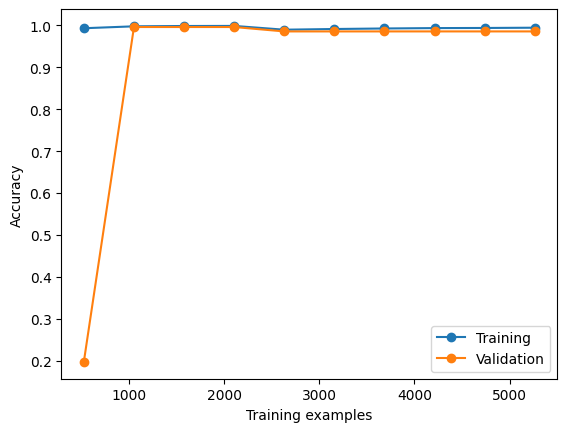

In [24]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', label="Training")
plt.plot(train_sizes, test_mean, 'o-', label="Validation")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [26]:
# Hapus duplikat berdasarkan kolom 'text_processed'
df_unique = df_all.drop_duplicates(subset=['text_processed'], keep='first')
print("Ukuran dataset setelah hapus duplikat:", len(df_unique))
print(df_unique['label'].value_counts())

Ukuran dataset setelah hapus duplikat: 1011
label
SENSITIF          552
TIDAK_SENSITIF    459
Name: count, dtype: int64


In [27]:
X = df_unique['text_processed']
y = df_unique['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline yang sama
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

      SENSITIF       0.95      1.00      0.97       111
TIDAK_SENSITIF       1.00      0.93      0.97        92

      accuracy                           0.97       203
     macro avg       0.97      0.97      0.97       203
  weighted avg       0.97      0.97      0.97       203



In [29]:
with open('model_naive_bayes.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("\nModel disimpan sebagai 'model_naive_bayes.pkl'")


Model disimpan sebagai 'model_naive_bayes.pkl'


In [30]:
# Contoh uji coba
test_texts = [
    "Password saya Admin123",
    "Halo apa kabar?",
    "NIK 1234567890123456",
    "Besok kuliah jam 8 pagi",
    "CVV kartu kredit 123"
]

for txt in test_texts:
    # Preprocessing dulu (pakai fungsi yang sama)
    clean = preprocess_text(txt)
    pred = pipeline.predict([clean])[0]
    prob = max(pipeline.predict_proba([clean])[0])
    print(f"Teks: {txt}\nPrediksi: {pred} ({prob:.2%})\n")

Teks: Password saya Admin123
Prediksi: SENSITIF (99.97%)

Teks: Halo apa kabar?
Prediksi: SENSITIF (53.10%)

Teks: NIK 1234567890123456
Prediksi: SENSITIF (54.58%)

Teks: Besok kuliah jam 8 pagi
Prediksi: TIDAK_SENSITIF (99.46%)

Teks: CVV kartu kredit 123
Prediksi: SENSITIF (99.88%)

